# DeGroot Consensus: Analysis Notebook

Loads simulation results across three topologies (Random Regular, Small-World, Hierarchy)
and three influence-weight conditions (Equal, Uniform, Log-Normal) and produces five
publication-quality analyses.

In [29]:
%matplotlib inline

import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy import stats

warnings.filterwarnings('ignore')

# ── Global style ────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.family':        'sans-serif',
    'font.size':          11,
    'axes.titlesize':     12,
    'axes.labelsize':     11,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    9,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          False,
    'xtick.direction':    'in',
    'ytick.direction':    'in',
    'xtick.major.size':   4,
    'ytick.major.size':   4,
    'lines.linewidth':    1.8,
    'figure.constrained_layout.use': True,
})

# ── Colour / style maps ─────────────────────────────────────────────────────
TOPO_COLORS = {
    'Random Regular': '#1a9641',
    'Small-World':    '#2166ac',
    'Hierarchy':      '#f4a41b'
}
WEIGHT_MARKERS = {
    'Equal':      'o',
    'Uniform':    's',
    'Log-Normal': '^',
}

TOPOS   = ['Random Regular', 'Small-World', 'Hierarchy']
WEIGHTS = ['Equal', 'Uniform', 'Log-Normal']

os.makedirs('figures', exist_ok=True)

def savefig(fig, name):
    fig.savefig(f'figures/{name}.png', dpi=300, bbox_inches='tight')
    fig.savefig(f'figures/{name}.pdf', bbox_inches='tight')
    print(f'  saved figures/{name}.{{png,pdf}}')

print('Setup complete.')

Setup complete.


## Data Loading

Load all 9 pickle files into a single tidy pandas DataFrame.

In [30]:
WEIGHT_DIR_MAP = {
    'equal':   'Equal',
    'uniform': 'Uniform',
    'skewed':  'Log-Normal',
}
TOPO_FILE_MAP = {
    'control':     'Random Regular',
    'alternative': 'Small-World',
    'hierarchy':   'Hierarchy',
}

log = 0 # flag for using the log-scaled test sizes instead of the linear ones
if log:
    BASE = 'results/inf_distr'
else:
    BASE = 'results/inf_distr_linspace'

KEEP = [
    'consensus_time', 'converged', 'spectral_gap',
    'lambda_2_modulus', 'predicted_convergence_time', 'final_disagreement',
]

rows = []
for wdir, wlabel in WEIGHT_DIR_MAP.items():
    for tfile, tlabel in TOPO_FILE_MAP.items():
        path = os.path.join(BASE, wdir, 'C_6', f'{tfile}.pkl')
        if not os.path.exists(path):
            print(f'  WARNING: missing {path} — skipping')
            continue
        with open(path, 'rb') as f:
            bag = pickle.load(f)
        for N, trials in bag.items():
            for t_idx, tr in enumerate(trials):
                row = {'weight_condition': wlabel, 'topology': tlabel,
                       'N': int(N), 'trial': t_idx}
                for k in KEEP:
                    row[k] = tr.get(k, np.nan)
                rows.append(row)

df = pd.DataFrame(rows)
df['predicted_convergence_time'] = df['predicted_convergence_time'].replace(
    [np.inf, -np.inf], np.nan)

print(f'Loaded {len(df):,} trial rows')
print(f'N values ({df["N"].nunique()} unique): {sorted(df["N"].unique())[:5]} ...')
df.head(4)

Loaded 3,600 trial rows
N values (20 unique): [np.int64(11), np.int64(536), np.int64(1061), np.int64(1586), np.int64(2111)] ...


,weight_condition,topology,N,trial,consensus_time,converged,spectral_gap,lambda_2_modulus,predicted_convergence_time,final_disagreement
0,Equal,Random Regular,11,0,12,True,0.604468,0.395532,14.895059,8.392803e-07
1,Equal,Random Regular,11,1,13,True,0.632891,0.367109,13.786609,6.015652e-07
2,Equal,Random Regular,11,2,16,True,0.574697,0.425303,16.159392,6.398728e-07
3,Equal,Random Regular,11,3,16,True,0.573880,0.426120,16.195745,4.359147e-07


---
## Analysis 1: Scaling Curves with Power-Law Exponents

Log-log plots of predicted convergence time vs. group size N, one panel per weight condition.
OLS on log-log scale gives the scaling exponent α (convergence time ∝ N^α).
A steeper slope means worse scaling with size.

  saved figures/analysis1_scaling_curves.{png,pdf}


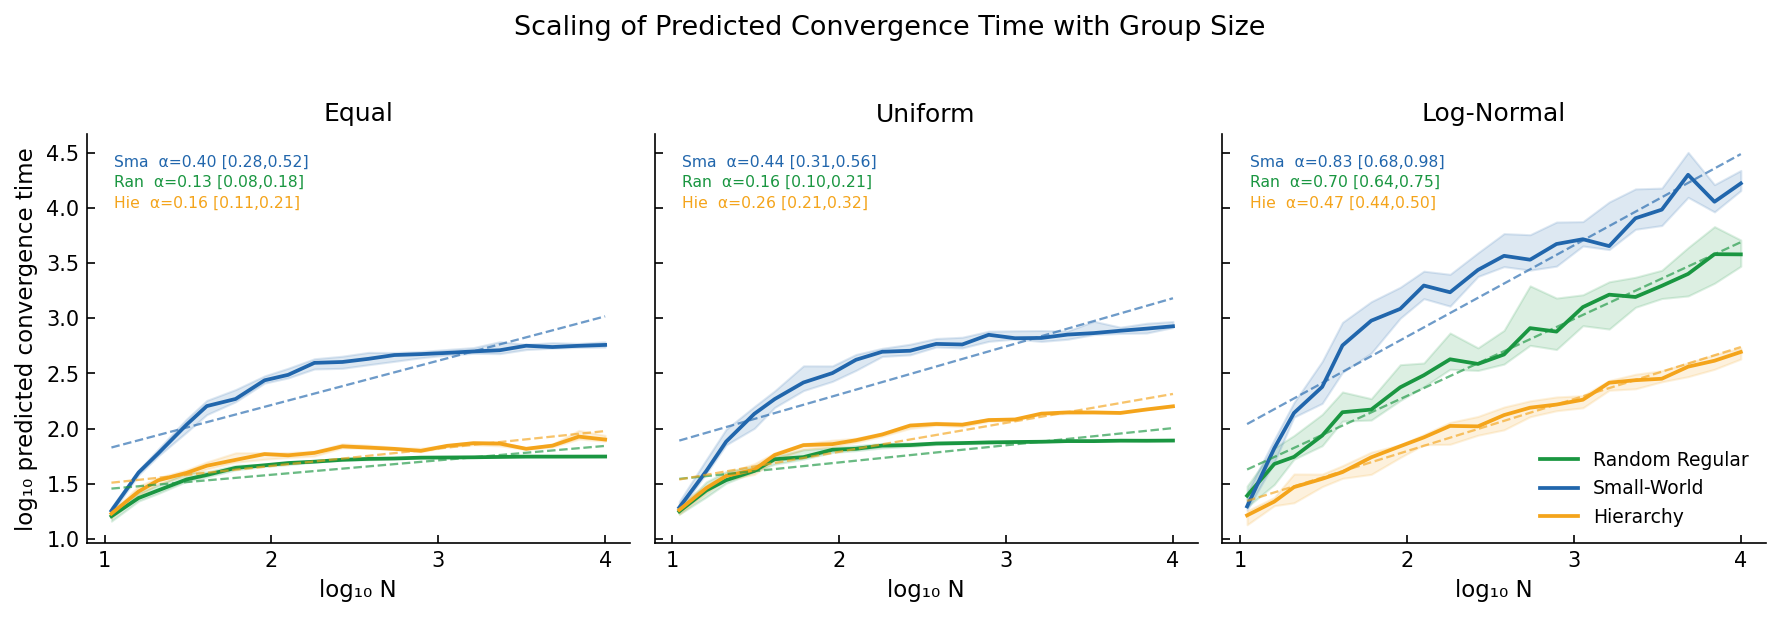

In [27]:
from scipy.stats import t as t_dist

def ols_powerlaw(log_N, log_t):
    """OLS on log-log data; returns (alpha, beta, lo95, hi95)."""
    mask = np.isfinite(log_N) & np.isfinite(log_t)
    x, y = log_N[mask], log_t[mask]
    n = len(x)
    if n < 4:
        return np.nan, np.nan, np.nan, np.nan
    xbar = x.mean()
    Sxx  = ((x - xbar) ** 2).sum()
    alpha = ((x - xbar) * y).sum() / Sxx
    beta  = y.mean() - alpha * xbar
    resid = y - (alpha * x + beta)
    s2    = (resid ** 2).sum() / (n - 2)
    se    = np.sqrt(s2 / Sxx)
    tc    = t_dist.ppf(0.975, df=n - 2)
    return alpha, beta, alpha - tc * se, alpha + tc * se


fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
exponent_records = []
display_order = {'Small-World': 0, 'Random Regular': 1, 'Hierarchy': 2}

for ax, wc in zip(axes, WEIGHTS):
    sub = df[(df['weight_condition'] == wc) &
             df['predicted_convergence_time'].notna()].copy()
    sub['log_N'] = np.log(sub['N'])
    sub['log_t'] = np.log(sub['predicted_convergence_time'])

    for topo in TOPOS:
        ts    = sub[sub['topology'] == topo]
        color = TOPO_COLORS[topo]

        grp = ts.groupby('N')['predicted_convergence_time']
        med  = grp.median()
        q25  = grp.quantile(0.25)
        q75  = grp.quantile(0.75)
        Nv   = med.index.values

        ax.plot(np.log10(Nv), np.log10(med.values),
                color=color, label=topo, zorder=3)
        ax.fill_between(np.log10(Nv),
                        np.log10(np.maximum(q25.values, 1e-3)),
                        np.log10(np.maximum(q75.values, 1e-3)),
                        color=color, alpha=0.15, zorder=2)

        # NEW CODE: Fit only on the medians
        log_N_med = np.log(med.index.values)
        log_t_med = np.log(med.values)

        alpha, beta, alo, ahi = ols_powerlaw(log_N_med, log_t_med)
        exponent_records.append(
            dict(weight=wc, topology=topo, alpha=alpha, alpha_lo=alo, alpha_hi=ahi))

        if np.isfinite(alpha):
            lN      = np.array([ts['log_N'].min(), ts['log_N'].max()])
            lT_fit  = alpha * lN + beta
            ax.plot(lN / np.log(10), lT_fit / np.log(10),
                    color=color, ls='--', lw=1.1, alpha=0.65, zorder=4)
            y_ann = 0.95 - 0.05 * display_order[topo]
            ax.text(0.05, y_ann,
                    f'{topo[:3]}  α={alpha:.2f} [{alo:.2f},{ahi:.2f}]',
                    transform=ax.transAxes, fontsize=7.5,
                    color=color, va='top')

    ax.set_title(wc)
    ax.set_xlabel('log₁₀ N')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=4))

axes[0].set_ylabel('log₁₀ predicted convergence time')

handles = [Line2D([0], [0], color=TOPO_COLORS[t], label=t) for t in TOPOS]
axes[2].legend(handles=handles, loc='lower right', frameon=False)

fig.suptitle('Scaling of Predicted Convergence Time with Group Size',
             fontsize=13, y=1.02)
plt.tight_layout()
savefig(fig, 'analysis1_scaling_curves')
plt.show()

---
## Analysis 2: Topology × Weight Condition Interaction

At the largest N with complete data for all nine conditions, median predicted convergence
time is shown as an interaction plot. The crossing of lines — hierarchy faster only under
heterogeneous influence — is the central empirical claim.

Representative N = 9996
  saved figures/analysis2_interaction.{png,pdf}


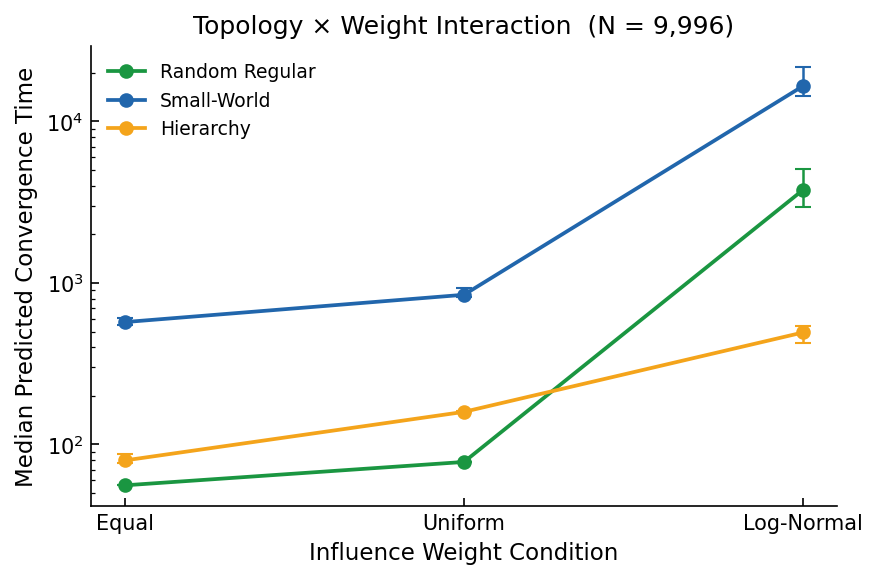

In [13]:
finite = df[df['predicted_convergence_time'].notna()]

# largest N with at least one finite trial in every (topology, weight) cell
coverage = finite.groupby(['N', 'topology', 'weight_condition']).size().unstack(
    ['topology', 'weight_condition'])
complete = coverage.dropna().index
rep_N = int(complete.max()) if len(complete) else int(finite['N'].max())
print(f'Representative N = {rep_N}')

sub = finite[finite['N'] == rep_N]
agg = sub.groupby(['topology', 'weight_condition'])['predicted_convergence_time'].agg(
    median='median',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
).reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
x_arr = np.arange(len(WEIGHTS))

for topo in TOPOS:
    td   = agg[agg['topology'] == topo].set_index('weight_condition')
    meds = np.array([td.loc[wc, 'median'] if wc in td.index else np.nan for wc in WEIGHTS])
    q25s = np.array([td.loc[wc, 'q25']    if wc in td.index else np.nan for wc in WEIGHTS])
    q75s = np.array([td.loc[wc, 'q75']    if wc in td.index else np.nan for wc in WEIGHTS])
    color = TOPO_COLORS[topo]

    ax.plot(x_arr, meds, color=color, marker='o', label=topo, zorder=3)
    ax.errorbar(x_arr, meds,
                yerr=[meds - q25s, q75s - meds],
                fmt='none', color=color, capsize=4, lw=1.2, zorder=2)

ax.set_xticks(x_arr)
ax.set_xticklabels(WEIGHTS)
ax.set_xlabel('Influence Weight Condition')
ax.set_ylabel('Median Predicted Convergence Time')
ax.set_yscale('log')
ax.set_title(f'Topology × Weight Interaction  (N = {rep_N:,})')
ax.legend(frameon=False)

plt.tight_layout()
savefig(fig, 'analysis2_interaction')
plt.show()

---
## Analysis 3: Threshold Sweep — Influence Skewness Crossover

New data is generated by sweeping the log-normal σ parameter from near-zero to 2.0.
At σ ≈ 0 all weights are equal (exp(0) = 1); at large σ influence is heavily skewed.
We ask: at what σ does hierarchy first become faster than both flat topologies?

In [31]:
import sys
sys.path.insert(0, '.')
from generator import generator, valid_tree_sizes
from engine import run_trial as eng_run_trial

TARGET_N  = 1000
C_SW      = 6
b_SW      = int(C_SW - 1)
N_TRIALS  = 20

valid_sizes = valid_tree_sizes(b_SW, 2000)
snap_N = int(valid_sizes[np.argmin(np.abs(valid_sizes - TARGET_N))])
print(f'Snapped N = {snap_N}')

SIGMAS      = np.concatenate([[0.01], np.linspace(0.1, 2.0, 18)])
TOPO_FILES  = ['control', 'alternative', 'hierarchy']
TOPO_LABELS = ['Random Regular', 'Small-World', 'Hierarchy']

graph_rng    = np.random.default_rng(99)
dynamics_rng = np.random.default_rng(77)

sweep_rows = []
for s_idx, sigma in enumerate(SIGMAS):
    print(f'  sigma={sigma:.3f}  ({s_idx+1}/{len(SIGMAS)})', flush=True)
    for tfile, tlabel in zip(TOPO_FILES, TOPO_LABELS):
        for _ in range(N_TRIALS):
            adj, w = generator(tfile, C_SW, snap_N,
                               weight_dist='skewed', rng=graph_rng, sigma=sigma)
            res = eng_run_trial(adj, w, rng=dynamics_rng, max_steps=50_000)
            pct = res['predicted_convergence_time']
            if not np.isfinite(pct):
                pct = np.nan
            sweep_rows.append({'sigma': sigma, 'topology': tlabel, 'pct': pct})

sweep_df = pd.DataFrame(sweep_rows)
print('Sweep complete.')

Snapped N = 1001
  sigma=0.010  (1/19)
  sigma=0.100  (2/19)
  sigma=0.212  (3/19)
  sigma=0.324  (4/19)
  sigma=0.435  (5/19)
  sigma=0.547  (6/19)
  sigma=0.659  (7/19)
  sigma=0.771  (8/19)
  sigma=0.882  (9/19)
  sigma=0.994  (10/19)
  sigma=1.106  (11/19)
  sigma=1.218  (12/19)
  sigma=1.329  (13/19)
  sigma=1.441  (14/19)
  sigma=1.553  (15/19)
  sigma=1.665  (16/19)
  sigma=1.776  (17/19)
  sigma=1.888  (18/19)
  sigma=2.000  (19/19)
Sweep complete.


Crossover sigma (hier vs RR, interpolated) = 0.6864
  saved figures/analysis3_sigma_sweep.{png,pdf}


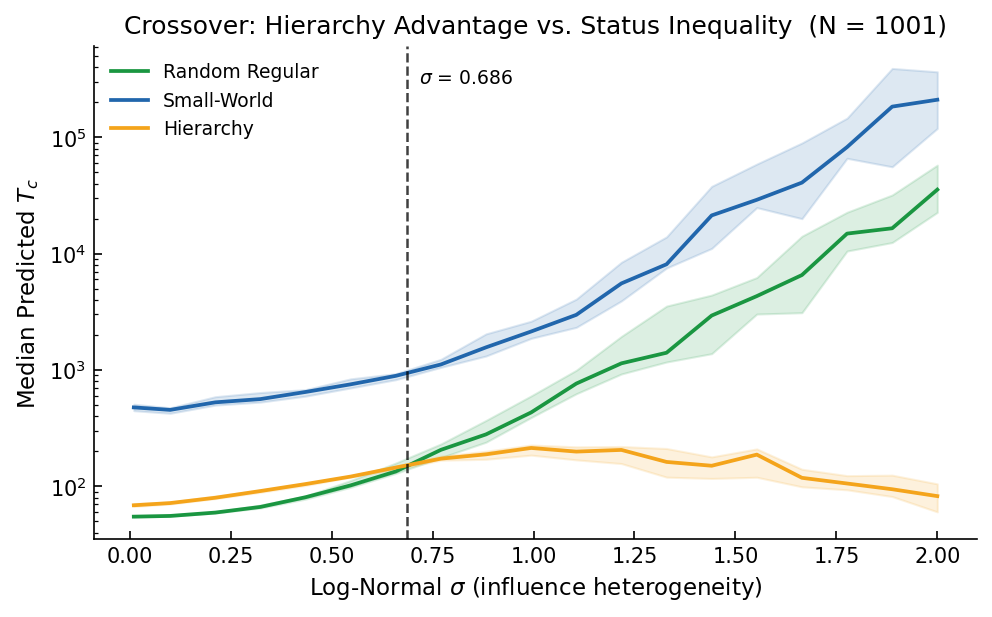

In [32]:
fig, ax = plt.subplots(figsize=(6.5, 4))

medians_by_topo = {}
for topo in TOPO_LABELS:
    td   = sweep_df[sweep_df['topology'] == topo]
    grp  = td.groupby('sigma')['pct']
    med  = grp.median()
    q25  = grp.quantile(0.25)
    q75  = grp.quantile(0.75)
    medians_by_topo[topo] = med
    color = TOPO_COLORS[topo]
    ax.plot(med.index, med.values, color=color, label=topo)
    ax.fill_between(med.index, q25.values, q75.values,
                    color=color, alpha=0.15)

# Crossover: hierarchy vs. Random Regular only.
# Small-World is consistently slower than RR, so comparing hierarchy vs. both
# simultaneously shifts the marker to the later (RR) crossing.
# We use linear interpolation between the two bracketing sigma steps
# to avoid snapping to the nearest grid point (~0.1 step error).
crossover_sigma = None
sig_vals = medians_by_topo['Hierarchy'].index.values
hier_med = medians_by_topo['Hierarchy'].values
rr_med   = medians_by_topo['Random Regular'].reindex(sig_vals).values

for i in range(1, len(sig_vals)):
    if not (np.isfinite(hier_med[i]) and np.isfinite(rr_med[i]) and
            np.isfinite(hier_med[i-1]) and np.isfinite(rr_med[i-1])):
        continue
    if hier_med[i] < rr_med[i] and hier_med[i-1] >= rr_med[i-1]:
        # hier was above (or equal) at i-1 and below at i
        diff_left  = hier_med[i-1] - rr_med[i-1]   # >= 0
        diff_right = rr_med[i]     - hier_med[i]    # > 0
        frac = diff_left / (diff_left + diff_right)
        crossover_sigma = float(sig_vals[i-1] + frac * (sig_vals[i] - sig_vals[i-1]))
        break

ylo, yhi = ax.get_ylim()
if crossover_sigma is not None:
    ax.axvline(crossover_sigma, color='black', ls='--', lw=1.2, alpha=0.75)
    ax.text(crossover_sigma + 0.03, yhi * 0.95,
            f'$\sigma$ = {crossover_sigma:.3f}', va='top', fontsize=9)
    print(f'Crossover sigma (hier vs RR, interpolated) = {crossover_sigma:.4f}')
else:
    print('No crossover detected in sigma in [0.01, 2.0]')

ax.set_xlabel('Log-Normal $\sigma$ (influence heterogeneity)')
ax.set_ylabel('Median Predicted $T_c$')
ax.set_yscale('log')
ax.set_title(f'Crossover: Hierarchy Advantage vs. Status Inequality  (N = {snap_N})')
ax.legend(frameon=False)

savefig(fig, 'analysis3_sigma_sweep')
plt.show()

---
## Analysis 4: Simulation vs. Spectral Prediction Agreement

Validates the spectral-gap proxy used throughout. Each point is one trial;
agreement with y = x confirms that 1/(1−|λ₂|) reliably predicts simulation dynamics.

Excluded 0 / 3600 rows with inf/NaN predicted_convergence_time
Pearson  r = 0.8776  (p = 0.00e+00)
Spearman ρ = 0.9962  (p = 0.00e+00)
  saved figures/analysis4_spectral_validation.{png,pdf}


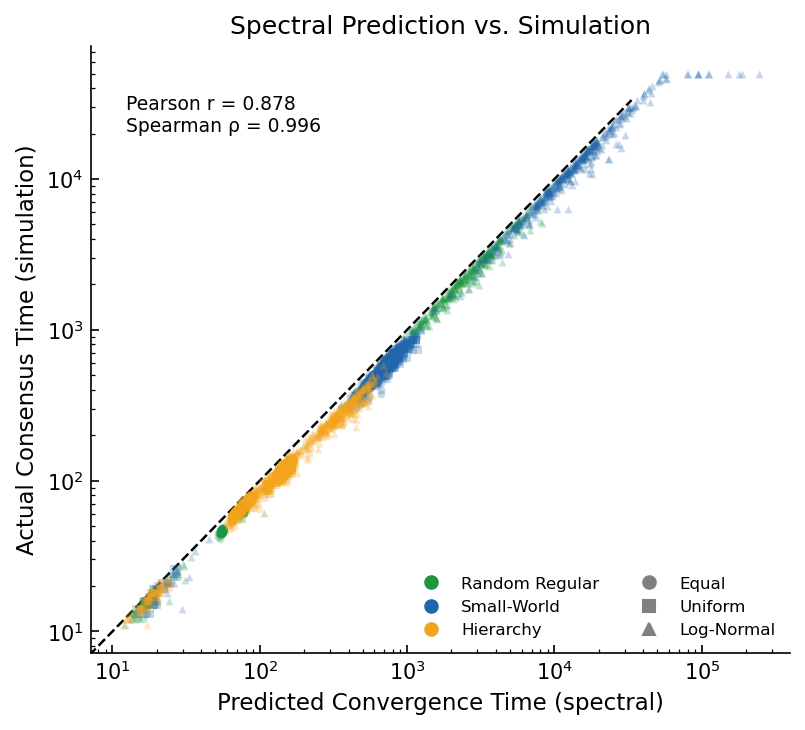

In [24]:
valid = df[df['predicted_convergence_time'].notna() &
           df['consensus_time'].notna()].copy()

n_inf_pct = df['predicted_convergence_time'].isna().sum()
n_total   = len(df)
print(f'Excluded {n_inf_pct} / {n_total} rows with inf/NaN predicted_convergence_time')

pearson_r,  p_pearson  = stats.pearsonr(
    valid['predicted_convergence_time'], valid['consensus_time'])
spearman_r, p_spearman = stats.spearmanr(
    valid['predicted_convergence_time'], valid['consensus_time'])
print(f'Pearson  r = {pearson_r:.4f}  (p = {p_pearson:.2e})')
print(f'Spearman ρ = {spearman_r:.4f}  (p = {p_spearman:.2e})')

fig, ax = plt.subplots(figsize=(5.5, 5))

for topo in TOPOS:
    for wc in WEIGHTS:
        td = valid[(valid['topology'] == topo) &
                   (valid['weight_condition'] == wc)]
        ax.scatter(
            td['predicted_convergence_time'], td['consensus_time'],
            color=TOPO_COLORS[topo], marker=WEIGHT_MARKERS[wc],
            alpha=0.25, s=14, linewidths=0, zorder=2,
        )

lim_max = np.nanpercentile(
    np.concatenate([valid['predicted_convergence_time'].values,
                    valid['consensus_time'].values]), 99) * 1.1
ax.plot([0, lim_max], [0, lim_max], 'k--', lw=1.2, label='y = x', zorder=1)

ax.set_xlabel('Predicted Convergence Time (spectral)')
ax.set_ylabel('Actual Consensus Time (simulation)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Spectral Prediction vs. Simulation')
ax.text(0.05, 0.92,
        f'Pearson r = {pearson_r:.3f}\nSpearman ρ = {spearman_r:.3f}',
        transform=ax.transAxes, fontsize=9, va='top')

topo_handles = [Line2D([0],[0], color=TOPO_COLORS[t], lw=0,
                       marker='o', markersize=6, label=t) for t in TOPOS]
wt_handles   = [Line2D([0],[0], color='grey', lw=0,
                       marker=WEIGHT_MARKERS[w], markersize=6, label=w)
                for w in WEIGHTS]
ax.legend(handles=topo_handles + wt_handles, frameon=False,
          ncol=2, fontsize=8, loc='lower right')

plt.tight_layout()
savefig(fig, 'analysis4_spectral_validation')
plt.show()

---
## Analysis 5: Functional Form Comparison (Log, Power-Law, Linear)

For each of the nine topology × weight cells we fit three candidate models and select
the best by AIC. A 3 × 3 grid overlays the best-fit curve on the data.

In [20]:
def aic_ols(y, y_hat, k):
    n    = len(y)
    rss  = np.sum((y - y_hat) ** 2)
    s2   = rss / n
    if s2 <= 0:
        return np.inf
    return n * np.log(s2) + 2 * k

def fit_log(N_arr, t_arr):
    mask = np.isfinite(N_arr) & np.isfinite(t_arr) & (N_arr > 0)
    x, y = np.log(N_arr[mask]), t_arr[mask]
    a, b = np.polyfit(x, y, 1)
    return a, b, aic_ols(y, a * x + b, 2)

def fit_powerlaw(N_arr, t_arr):
    mask = np.isfinite(N_arr) & np.isfinite(t_arr) & (N_arr > 0) & (t_arr > 0)
    x, y = np.log(N_arr[mask]), np.log(t_arr[mask])
    a, b = np.polyfit(x, y, 1)
    return a, b, aic_ols(np.exp(y), np.exp(a * x + b), 2)

def fit_linear(N_arr, t_arr):
    mask = np.isfinite(N_arr) & np.isfinite(t_arr)
    x, y = N_arr[mask], t_arr[mask]
    a, b = np.polyfit(x, y, 1)
    return a, b, aic_ols(y, a * x + b, 2)

table_rows = []
fit_store  = {}

for topo in TOPOS:
    for wc in WEIGHTS:
        td = df[(df['topology'] == topo) &
                (df['weight_condition'] == wc) &
                df['predicted_convergence_time'].notna()].copy()
        N_arr = td['N'].values.astype(float)
        t_arr = td['predicted_convergence_time'].values
        try:
            a_l,   b_l,   aic_l   = fit_log(N_arr, t_arr)
            a_p,   b_p,   aic_p   = fit_powerlaw(N_arr, t_arr)
            a_lin, b_lin, aic_lin = fit_linear(N_arr, t_arr)
        except Exception as e:
            print(f'  fit error {topo}/{wc}: {e}')
            continue
        aics = {'Logarithmic': aic_l, 'Power-Law': aic_p, 'Linear': aic_lin}
        best = min(aics, key=aics.get)
        table_rows.append({
            'topology': topo, 'weight_condition': wc,
            'log_aic':      round(aic_l,   1),
            'powerlaw_aic': round(aic_p,   1),
            'linear_aic':   round(aic_lin, 1),
            'best_model':   best,
        })
        fit_store[(topo, wc)] = {
            'best': best,
            'log':      (a_l,   b_l),
            'powerlaw': (a_p,   b_p),
            'linear':   (a_lin, b_lin),
        }

aic_table = pd.DataFrame(table_rows)
print(aic_table.to_string(index=False))

      topology weight_condition  log_aic  powerlaw_aic  linear_aic  best_model
Random Regular            Equal   1132.1        1450.5      1662.4 Logarithmic
Random Regular          Uniform   1431.5        1809.1      1977.9 Logarithmic
Random Regular       Log-Normal   6209.3        6207.4      6200.5      Linear
   Small-World            Equal   3408.8        3973.9      3822.3 Logarithmic
   Small-World          Uniform   3822.9        4307.6      4146.8 Logarithmic
   Small-World       Log-Normal   8013.9        8023.0      8013.6      Linear
     Hierarchy            Equal   1807.6        1887.3      2045.4 Logarithmic
     Hierarchy          Uniform   1764.0        2306.0      2503.4 Logarithmic
     Hierarchy       Log-Normal   3527.5        3402.4      3486.1   Power-Law


  saved figures/analysis5_functional_form.{png,pdf}


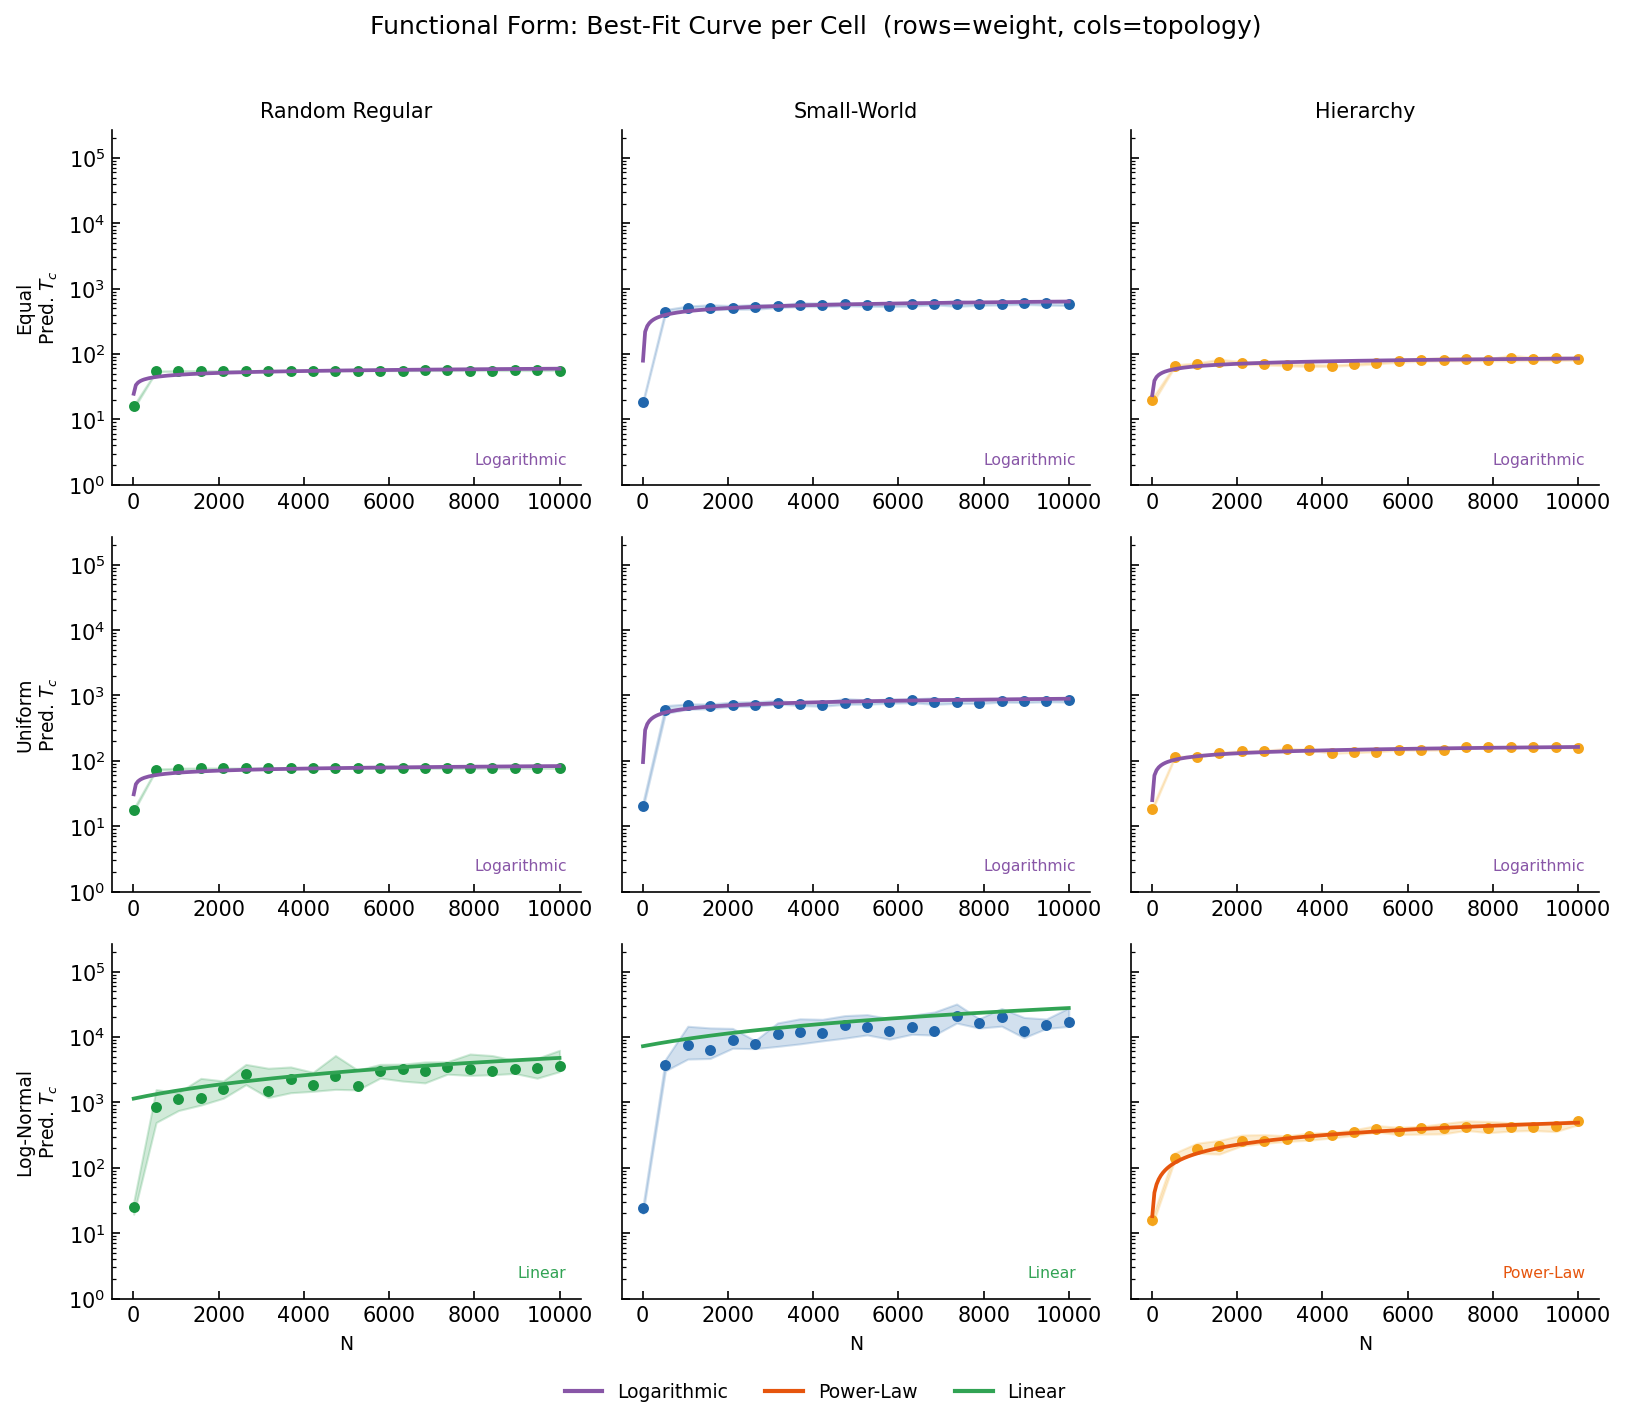

In [21]:
MODEL_COLORS = {
    'Logarithmic': '#8856a7',
    'Power-Law':   '#e6550d',
    'Linear':      '#31a354',
}

fig, axes = plt.subplots(3, 3, figsize=(11, 9), sharey=True)

y_min = 1 # Log scales cannot start at 0
y_max = df['predicted_convergence_time'].max() * 1.1 

for row_i, wc in enumerate(WEIGHTS):
    for col_j, topo in enumerate(TOPOS):
        ax = axes[row_i][col_j]
        td = df[(df['topology'] == topo) &
                (df['weight_condition'] == wc) &
                df['predicted_convergence_time'].notna()]

        grp = td.groupby('N')['predicted_convergence_time']
        med = grp.median()
        q25 = grp.quantile(0.25)
        q75 = grp.quantile(0.75)
        Nv  = med.index.values.astype(float)

        ax.scatter(Nv, med.values, s=18, color=TOPO_COLORS[topo], zorder=3)
        ax.fill_between(Nv, q25.values, q75.values,
                        color=TOPO_COLORS[topo], alpha=0.2, zorder=2)

        if (topo, wc) in fit_store:
            fs   = fit_store[(topo, wc)]
            best = fs['best']
            Nfit = np.linspace(Nv.min(), Nv.max(), 200)
            if best == 'Logarithmic':
                a, b  = fs['log']
                y_fit = a * np.log(Nfit) + b
            elif best == 'Power-Law':
                a, b  = fs['powerlaw']
                y_fit = np.exp(b) * Nfit ** a
            else:
                a, b  = fs['linear']
                y_fit = a * Nfit + b
            ax.plot(Nfit, y_fit, color=MODEL_COLORS[best], lw=1.8, zorder=4)
            ax.text(0.97, 0.05, best, transform=ax.transAxes,
                    ha='right', va='bottom', fontsize=7.5, color=MODEL_COLORS[best])

        ax.set_yscale('log')
        ax.set_ylim(y_min, y_max)

        if row_i == 0:
            ax.set_title(topo, fontsize=10)
        if col_j == 0:
            ax.set_ylabel(f'{wc}\nPred. $T_c$', fontsize=9)
        if row_i == 2:
            ax.set_xlabel('N', fontsize=9)

fig.suptitle('Functional Form: Best-Fit Curve per Cell  (rows=weight, cols=topology)',
             fontsize=12, y=1.01)

model_handles = [Line2D([0],[0], color=c, label=m, lw=2)
                 for m, c in MODEL_COLORS.items()]
fig.legend(handles=model_handles, loc='lower center',
           ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
savefig(fig, 'analysis5_functional_form')
plt.show()

---
## Summary of Key Numerical Findings

In [28]:
print('=' * 64)
print('KEY NUMERICAL FINDINGS')
print('=' * 64)

print('\n── Analysis 1: Power-Law Scaling Exponents ──────────────────')
exp_df = pd.DataFrame(exponent_records)
for _, row in exp_df.iterrows():
    if np.isfinite(row['alpha']):
        print(f'  {row["topology"]:15s} / {row["weight"]:10s}  '
              f'α = {row["alpha"]:+.3f}  95% CI [{row["alpha_lo"]:+.3f}, {row["alpha_hi"]:+.3f}]')

print(f'\n── Analysis 2: Interaction at N = {rep_N:,} ──────────────────')
for _, r in agg.sort_values(['weight_condition','topology']).iterrows():
    print(f'  {r["topology"]:15s} / {r["weight_condition"]:10s}  '
          f'median PCT = {r["median"]:,.0f}')

print('\n── Analysis 3: Sigma Crossover ──────────────────────────────')
if crossover_sigma is not None:
    print(f'  Hierarchy becomes fastest at σ ≈ {crossover_sigma:.3f}')
else:
    print('  No crossover detected in σ ∈ [0.01, 2.0]')

print('\n── Analysis 4: Spectral–Simulation Correlation ──────────────')
print(f'  Pearson  r = {pearson_r:.4f}')
print(f'  Spearman ρ = {spearman_r:.4f}')
print(f'  Inf/NaN PCT excluded: {n_inf_pct} / {n_total}')

print('\n── Analysis 5: Best Functional Form ────────────────────────')
print(aic_table[['topology','weight_condition','best_model']].to_string(index=False))
print('=' * 64)

KEY NUMERICAL FINDINGS

── Analysis 1: Power-Law Scaling Exponents ──────────────────
  Random Regular  / Equal       α = +0.161  95% CI [+0.153, +0.170]
  Small-World     / Equal       α = +0.451  95% CI [+0.429, +0.473]
  Hierarchy       / Equal       α = +0.196  95% CI [+0.186, +0.206]
  Random Regular  / Uniform     α = +0.188  95% CI [+0.177, +0.198]
  Small-World     / Uniform     α = +0.481  95% CI [+0.458, +0.505]
  Hierarchy       / Uniform     α = +0.289  95% CI [+0.278, +0.299]
  Random Regular  / Log-Normal  α = +0.704  95% CI [+0.665, +0.742]
  Small-World     / Log-Normal  α = +0.919  95% CI [+0.872, +0.967]
  Hierarchy       / Log-Normal  α = +0.483  95% CI [+0.469, +0.498]

── Analysis 2: Interaction at N = 9,996 ──────────────────
  Hierarchy       / Equal       median PCT = 85
  Random Regular  / Equal       median PCT = 56
  Small-World     / Equal       median PCT = 582
  Hierarchy       / Log-Normal  median PCT = 512
  Random Regular  / Log-Normal  median PCT = 3,5